# 🧹 Data Cleaning Notebook
## Short-Form Video Consumption & Attention Span Study

---

| Field | Details |
|---|---|
| **Dataset** | `reels_attention_span_dirty.csv` |
| **Raw Rows** | 12,000 |
| **Expected Clean Rows** | ~8,900 |
| **Columns** | 10 |
| **Course** | Data Visualisation & Analytics (DVA) |

---

## 📋 Cleaning Roadmap

| Step | Task |
|---|---|
| 1 | Import libraries & load data |
| 2 | Initial inspection |
| 3 | Fix data types (object → numeric) |
| 4 | Standardise categorical columns |
| 5 | Remove impossible / invalid values |
| 6 | Handle missing values |
| 7 | Detect & treat outliers |
| 8 | Remove duplicates |
| 9 | Final validation & save |


---
## Step 1 — Import Libraries & Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a1a',
    'axes.edgecolor':    '#333',
    'axes.labelcolor':   '#ccc',
    'xtick.color':       '#888',
    'ytick.color':       '#888',
    'text.color':        '#eee',
    'grid.color':        '#2a2a2a',
    'grid.linestyle':    '--',
    'axes.titlecolor':   '#fff',
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'legend.facecolor':  '#1e1e1e',
    'legend.edgecolor':  '#444',
})

C_TEAL  = '#7eb8a4'
C_AMBER = '#e8c97a'
C_CORAL = '#c97b6b'
C_BLUE  = '#8b9ed4'

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [8]:
# ── Load raw dataset ───────────────────────────────────────────────
# If on Colab, upload the file first:
# from google.colab import files
# files.upload()

df_raw = pd.read_csv('../data/raw/raw_attention_study_data.csv')



print(f"Raw dataset shape : {df_raw.shape}")
print(f"Total cells       : {df_raw.shape[0] * df_raw.shape[1]:,}")
df_raw.head(10)

Raw dataset shape : (12350, 15)
Total cells       : 185,250


,user_id,age,gender,location,platform,reels_watch_time_hours,daily_screen_time_hours,scrolling_sessions_day,notifications_per_day,sleep_hours,physical_activity_hours_week,stress_level,attention_span_score,focus_level,task_completion_rate
0,USR00001,17.0,Female,Urban,TikTok,3.81,12.94,10,31.0,8.12,3.0,hi,6.75,4.24,38.7
1,USR00002,31.0,male,Suburban,Instagram Reels,1.69,7.25,3,1.0,8.15,4.6,Low,10.00,7.29,49.8
2,USR00003,23.0,Female,Rural,Instagram Reels,3.99,10.38,9,31.0,7.10,3.5,Low,8.42,5.99,41.2
3,USR00004,20.0,Male,Rural,Instagram Reels,3.94,9.28,13,52.0,6.81,2.9,Medium,6.75,6.47,27.0
4,USR00005,37.0,f,Urban,Instagram Reels,0.30,3.88,3,2.0,8.39,7.3,Low,9.23,8.18,71.0
5,USR00006,34.0,Male,Suburban,YouTube Shorts,1.50,4.84,1,0.0,5.56,5.8,Medium,7.62,8.23,49.4
6,USR00007,31.0,Female,Urban,YouTube Shorts,2.95,9.22,6,27.0,9.18,4.6,Medium,7.80,4.74,33.5
7,USR00008,23.0,Female,Urban,Instagram Reels,4.35,9.45,9,24.0,5.90,2.6,High,5.95,2.34,29.0
8,USR00009,21.0,Female,Suburban,Instagram Reels,4.00,11.17,12,44.0,6.99,1.9,MEDIUM,5.37,3.99,36.1
9,USR00010,27.0,Female,Urban,Instagram Reels,3.42,9.05,2,6.0,6.93,3.8,Medium,8.12,4.8,27.6


---
## Step 2 — Initial Inspection
> Understand what we are dealing with before touching anything.

In [9]:
# ── Data types and non-null counts ────────────────────────────────
print("=" * 55)
print("COLUMN INFO")
print("=" * 55)
df_raw.info()

COLUMN INFO
<class 'pandas.DataFrame'>
RangeIndex: 12350 entries, 0 to 12349
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       12350 non-null  str    
 1   age                           12166 non-null  float64
 2   gender                        11980 non-null  str    
 3   location                      12350 non-null  str    
 4   platform                      12350 non-null  str    
 5   reels_watch_time_hours        12330 non-null  float64
 6   daily_screen_time_hours       12350 non-null  float64
 7   scrolling_sessions_day        12350 non-null  int64  
 8   notifications_per_day         12128 non-null  float64
 9   sleep_hours                   12104 non-null  float64
 10  physical_activity_hours_week  11856 non-null  float64
 11  stress_level                  12350 non-null  str    
 12  attention_span_score          12350 non-null  float64
 13  

In [10]:
# ── Basic statistics ──────────────────────────────────────────────
print("DESCRIPTIVE STATISTICS — Raw Data")
df_raw.describe(include='all').round(3)

DESCRIPTIVE STATISTICS — Raw Data


,user_id,age,gender,location,platform,reels_watch_time_hours,daily_screen_time_hours,scrolling_sessions_day,notifications_per_day,sleep_hours,physical_activity_hours_week,stress_level,attention_span_score,focus_level,task_completion_rate
count,12350,12166.000,11980,12350,12350,12330.000,12350.00,12350.000,12128.000,12104.000,11856.000,12350,12350.000,12350,12042.000
unique,12350,NaN,21,3,28,NaN,NaN,NaN,NaN,NaN,NaN,26,NaN,772,NaN
top,USR00001,NaN,Female,Urban,Instagram Reels,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN,5.82,NaN
freq,1,NaN,5225,6420,3738,NaN,NaN,NaN,NaN,NaN,NaN,3687,NaN,51,NaN
mean,NaN,28.076,NaN,NaN,NaN,3.229,8.36,8.115,32.689,7.202,4.521,NaN,7.719,NaN,40.149
std,NaN,24.816,NaN,NaN,NaN,1.377,3.46,3.893,18.068,1.229,1.700,NaN,1.260,NaN,13.477
min,NaN,0.000,NaN,NaN,NaN,0.300,-2.00,1.000,0.000,-1.000,0.000,NaN,-1.000,NaN,-10.000
25%,NaN,21.000,NaN,NaN,NaN,2.220,6.23,5.000,19.000,6.500,3.400,NaN,6.852,NaN,30.900
50%,NaN,27.000,NaN,NaN,NaN,3.270,8.35,8.000,32.000,7.190,4.500,NaN,7.750,NaN,40.200
75%,NaN,34.000,NaN,NaN,NaN,4.230,10.35,11.000,45.000,7.890,5.700,NaN,8.630,NaN,49.400


MISSING VALUES SUMMARY
                              Missing Count  Missing %    Dtype
physical_activity_hours_week            494       4.00  float64
gender                                  370       3.00      str
task_completion_rate                    308       2.49  float64
sleep_hours                             246       1.99  float64
notifications_per_day                   222       1.80  float64
age                                     184       1.49  float64
reels_watch_time_hours                   20       0.16  float64
user_id                                   0       0.00      str
location                                  0       0.00      str
platform                                  0       0.00      str
daily_screen_time_hours                   0       0.00  float64
scrolling_sessions_day                    0       0.00    int64
stress_level                              0       0.00      str
attention_span_score                      0       0.00  float64
focus_level      

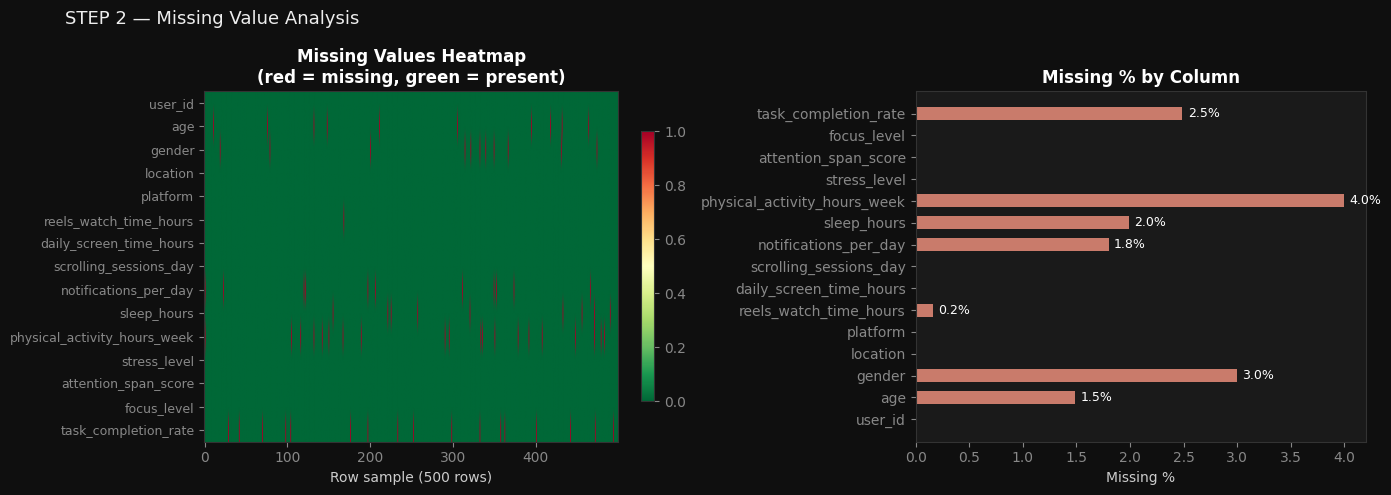

In [ ]:
# ── Missing value summary ─────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct,
    'Dtype':         df_raw.dtypes
}).sort_values('Missing %', ascending=False)

print("MISSING VALUES SUMMARY")
print(missing_df)

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("STEP 2 — Missing Value Analysis", x=0.05, ha='left', fontsize=13)

# Heatmap
missing_bool = df_raw.isnull()
sample_idx   = np.random.choice(len(df_raw), min(500, len(df_raw)), replace=False)
im = axes[0].imshow(missing_bool.iloc[sample_idx].T.astype(int),
                    aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_yticks(range(len(df_raw.columns)))
axes[0].set_yticklabels(df_raw.columns, fontsize=9)
axes[0].set_xlabel("Row sample (500 rows)")
axes[0].set_title("Missing Values Heatmap\n(red = missing, green = present)")
fig.colorbar(im, ax=axes[0], fraction=0.03)

# Bar chart
colors_bar = [C_CORAL if v > 0 else C_TEAL for v in missing_pct.values]
bars = axes[1].barh(missing_pct.index, missing_pct.values, color=colors_bar, height=0.6)
axes[1].set_xlabel("Missing %")
axes[1].set_title("Missing % by Column")
axes[1].axvline(0, color='white', linewidth=0.5)
for bar, val in zip(bars, missing_pct.values):
    if val > 0:
        axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9, color='white')

plt.tight_layout()
plt.show()

In [12]:
# ── Duplicate check ───────────────────────────────────────────────
n_dupes = df_raw.duplicated().sum()
print(f"Duplicate rows found : {n_dupes}")
print(f"That is {n_dupes/len(df_raw)*100:.2f}% of the dataset")

# Show a sample of duplicates
if n_dupes > 0:
    dupe_mask = df_raw.duplicated(keep=False)
    print(f"\nSample of duplicated rows:")
    display(df_raw[dupe_mask].sort_values('user_id').head(6))

Duplicate rows found : 0
That is 0.00% of the dataset


In [13]:
# ── Categorical column inspection ─────────────────────────────────
print("UNIQUE VALUES IN 'platform':")
print(df_raw['platform'].value_counts().to_string())
print()
print("UNIQUE VALUES IN 'stress_level':")
print(df_raw['stress_level'].value_counts().to_string())

# Check which numeric columns are stored as object (wrong dtype)
print()
print("COLUMNS WITH WRONG DTYPE (should be numeric but stored as object):")
for col in df_raw.columns:
    if df_raw[col].dtype == object and col not in ['platform','stress_level','gender','location']:
        print(f"  → {col}")
        print(f"     Sample non-numeric entries: {df_raw[col][pd.to_numeric(df_raw[col], errors='coerce').isna() & df_raw[col].notna()].unique()[:5]}")

UNIQUE VALUES IN 'platform':
platform
Instagram Reels       3738
YouTube Shorts        3557
TikTok                3532
Instagram reels        123
tik_tok                108
YT Shorts              105
TIKTOK                 103
Insta Reels            102
INSTAGRAM REELS        100
youtube shorts         100
YOUTUBE SHORTS          99
Tiktok                  97
instagram               96
Youtube Shorts          90
youtube_shorts          90
tiktok                  87
Tik Tok                 87
instagram reels         86
  YouTube Shorts        18
  Instagram Reels       13
  TikTok                11
  instagram reels        2
  Insta Reels            1
  youtube shorts         1
  instagram              1
  Youtube Shorts         1
  YT Shorts              1
  Tik Tok                1

UNIQUE VALUES IN 'stress_level':
stress_level
High          3687
Medium        3574
Low           3563
lo             138
L              125
LOW            115
MEDIUM         113
hi             112
H      

---
## Step 3 — Fix Data Types
> Some numeric columns were stored as `object` because they contained string garbage like `'N/A'` or `'unknown'`. We convert them to numeric — invalid strings automatically become `NaN` and get handled in Step 6.

In [14]:
# ── Work on a copy — never modify raw data ────────────────────────
df = df_raw.copy()

numeric_cols = [
    'age',
    'reels_watch_time_hours',
    'daily_screen_time_hours',
    'sleep_hours',
    'attention_span_score',
    'focus_level',
    'task_completion_rate'
]

# errors='coerce' turns any non-numeric string → NaN silently
for col in numeric_cols:
    before_nulls = df[col].isna().sum()
    df[col]      = pd.to_numeric(df[col], errors='coerce')
    after_nulls  = df[col].isna().sum()
    new_nulls    = after_nulls - before_nulls
    if new_nulls > 0:
        print(f"  {col:<30} → {new_nulls} new NaNs created (were non-numeric strings)")

print()
print("Updated dtypes:")
print(df[numeric_cols].dtypes)
print(f"\n All numeric columns now float64.")

  focus_level                    → 20 new NaNs created (were non-numeric strings)

Updated dtypes:
age                        float64
reels_watch_time_hours     float64
daily_screen_time_hours    float64
sleep_hours                float64
attention_span_score       float64
focus_level                float64
task_completion_rate       float64
dtype: object

 All numeric columns now float64.


---
## Step 4 — Standardise Categorical Columns
> The platform and stress_level columns have dozens of spelling variants, mixed cases, and extra whitespace. We map all of them to standard labels.

In [15]:
# ── Platform column ───────────────────────────────────────────────
print("BEFORE — Platform unique values:")
print(sorted(df['platform'].dropna().unique()))

# Step 1: strip whitespace, lowercase
df['platform'] = df['platform'].astype(str).str.strip().str.lower()

# Step 2: map all variants to clean labels
platform_map = {
    # TikTok variants
    'tiktok':          'TikTok',
    'tik tok':         'TikTok',
    'tik_tok':         'TikTok',
    'TIKTOK':          'TikTok',

    # Instagram variants
    'instagram reels': 'Instagram Reels',
    'instagram':       'Instagram Reels',
    'insta reels':     'Instagram Reels',
    'ig':              'Instagram Reels',
    'insta':           'Instagram Reels',

    # YouTube variants
    'youtube shorts':  'YouTube Shorts',
    'youtube':         'YouTube Shorts',
    'yt shorts':       'YouTube Shorts',
    'yt':              'YouTube Shorts',
    'youtube_shorts':  'YouTube Shorts',
    'youTube shorts':  'YouTube Shorts',
}
df['platform'] = df['platform'].map(platform_map)
# Anything not in the map becomes NaN → fill Unknown
df['platform'] = df['platform'].fillna('Unknown')

print("\nAFTER — Platform unique values:")
print(df['platform'].value_counts())

BEFORE — Platform unique values:
['  Insta Reels ', '  Instagram Reels ', '  Tik Tok ', '  TikTok ', '  YT Shorts ', '  YouTube Shorts ', '  Youtube Shorts ', '  instagram ', '  instagram reels ', '  youtube shorts ', 'INSTAGRAM REELS', 'Insta Reels', 'Instagram Reels', 'Instagram reels', 'TIKTOK', 'Tik Tok', 'TikTok', 'Tiktok', 'YOUTUBE SHORTS', 'YT Shorts', 'YouTube Shorts', 'Youtube Shorts', 'instagram', 'instagram reels', 'tik_tok', 'tiktok', 'youtube shorts', 'youtube_shorts']

AFTER — Platform unique values:
platform
Instagram Reels    4262
YouTube Shorts     4062
TikTok             4026
Name: count, dtype: int64


In [16]:
# ── Stress level column ───────────────────────────────────────────
print("BEFORE — Stress level unique values:")
print(sorted(df['stress_level'].dropna().unique()))

# Step 1: strip + title case
df['stress_level'] = df['stress_level'].astype(str).str.strip().str.title()

# Step 2: map all variants
stress_map = {
    # Low variants
    'Low':      'Low',
    'Lo':       'Low',
    'L':        'Low',
    'low':      'Low',

    # Medium variants
    'Medium':   'Medium',
    'Med':      'Medium',
    'Moderate': 'Medium',
    'M':        'Medium',

    # High variants
    'High':     'High',
    'Hi':       'High',
    'H':        'High',
    'Very High':'High',
}
df['stress_level'] = df['stress_level'].map(stress_map)
df['stress_level'] = df['stress_level'].fillna('Unknown')

print("\nAFTER — Stress level unique values:")
print(df['stress_level'].value_counts())

BEFORE — Stress level unique values:
['H', 'H  ', 'HIGH', 'HIGH  ', 'Hi', 'High', 'High  ', 'L', 'L  ', 'LOW', 'LOW  ', 'Low', 'Low  ', 'MEDIUM', 'MEDIUM  ', 'Med', 'Medium', 'Medium  ', 'Moderate', 'Moderate  ', 'hi', 'high', 'lo', 'low', 'med', 'medium']

AFTER — Stress level unique values:
stress_level
High      4200
Medium    4082
Low       4068
Name: count, dtype: int64


In [17]:
# ── Gender column (if present) ────────────────────────────────────
if 'gender' in df.columns:
    print("BEFORE — Gender unique values:")
    print(sorted(df['gender'].dropna().astype(str).str.strip().unique()))

    df['gender'] = df['gender'].astype(str).str.strip().str.title()

    gender_map = {
        'Male':       'Male',   'M': 'Male',
        'Female':     'Female', 'F': 'Female',
        'Non-Binary': 'Non-binary',
        'Nb':         'Non-binary',
        'Nonbinary':  'Non-binary',
        'Non-binary': 'Non-binary',
        'Nan':        np.nan,
    }
    df['gender'] = df['gender'].map(gender_map)
    df['gender'] = df['gender'].fillna('Unknown')

    print("\nAFTER — Gender unique values:")
    print(df['gender'].value_counts())
else:
    print("No gender column in this dataset — skipping.")

BEFORE — Gender unique values:
['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'NB', 'Non-Binary', 'Non-binary', 'f', 'female', 'm', 'male', 'non-binary', 'nonbinary']

AFTER — Gender unique values:
gender
Female        5962
Male          5482
Non-binary     536
Unknown        370
Name: count, dtype: int64


---
## Step 5 — Remove Impossible / Invalid Values
> Values that are physically impossible — negative ages, attention scores of 110, sleep of 30 hours — cannot be imputed meaningfully. We drop these rows entirely.

In [18]:
shape_before = df.shape[0]

# ── Valid range rules ──────────────────────────────────────────────
rules = {
    'age':                      (15, 80),
    'reels_watch_time_hours':   (0,  16),
    'daily_screen_time_hours':  (0,  24),
    'sleep_hours':              (1,  14),
    'attention_span_score':     (1,  10),
    'focus_level':              (1,  10),
    'task_completion_rate':     (0,  100),
}

print("Rows removed by each rule:")
print("-" * 45)
for col, (lo, hi) in rules.items():
    before = df.shape[0]
    df = df[df[col].isna() | df[col].between(lo, hi)]
    removed = before - df.shape[0]
    print(f"  {col:<30} → {removed:>4} rows removed (valid range: {lo}–{hi})")

# ── Logical constraint: reels ≤ total screen time ─────────────────
before = df.shape[0]
df = df[df['reels_watch_time_hours'].isna() |
        df['daily_screen_time_hours'].isna() |
        (df['reels_watch_time_hours'] <= df['daily_screen_time_hours'])]
removed = before - df.shape[0]
print(f"  {'reels <= screen_time (logic)':<30} → {removed:>4} rows removed")

print("-" * 45)
print(f"  Rows before : {shape_before:,}")
print(f"  Rows after  : {df.shape[0]:,}")
print(f"  Total removed: {shape_before - df.shape[0]:,}")

Rows removed by each rule:
---------------------------------------------
  age                            →   25 rows removed (valid range: 15–80)
  reels_watch_time_hours         →    0 rows removed (valid range: 0–16)
  daily_screen_time_hours        →   13 rows removed (valid range: 0–24)
  sleep_hours                    →   30 rows removed (valid range: 1–14)
  attention_span_score           →   15 rows removed (valid range: 1–10)
  focus_level                    →    0 rows removed (valid range: 1–10)
  task_completion_rate           →   18 rows removed (valid range: 0–100)
  reels <= screen_time (logic)   →   14 rows removed
---------------------------------------------
  Rows before : 12,350
  Rows after  : 12,235
  Total removed: 115


---
## Step 6 — Handle Missing Values
> After type conversion and range filtering, some NaNs still remain. We use **median imputation** for numeric columns (median is robust to skew) and keep `'Unknown'` for categoricals already handled in Step 4.

In [19]:
# ── Before imputation ─────────────────────────────────────────────
print("Missing values BEFORE imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# ── Median imputation for numeric columns ─────────────────────────
numeric_features = [
    'age', 'reels_watch_time_hours', 'daily_screen_time_hours',
    'sleep_hours', 'attention_span_score', 'focus_level', 'task_completion_rate'
]

medians = {}
for col in numeric_features:
    median_val = df[col].median()
    medians[col] = median_val
    missing_count = df[col].isna().sum()
    if missing_count > 0:
        df[col] = df[col].fillna(median_val)
        print(f"  {col:<30} → filled {missing_count} NaNs with median = {median_val:.3f}")

print()
print("Missing values AFTER imputation:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "  ✅ No missing values remain.")

Missing values BEFORE imputation:
age                             182
reels_watch_time_hours           20
notifications_per_day           220
sleep_hours                     244
physical_activity_hours_week    491
focus_level                      20
task_completion_rate            303
dtype: int64
  age                            → filled 182 NaNs with median = 27.000
  reels_watch_time_hours         → filled 20 NaNs with median = 3.270
  sleep_hours                    → filled 244 NaNs with median = 7.190
  focus_level                    → filled 20 NaNs with median = 5.500
  task_completion_rate           → filled 303 NaNs with median = 40.200

Missing values AFTER imputation:
notifications_per_day           220
physical_activity_hours_week    491
dtype: int64


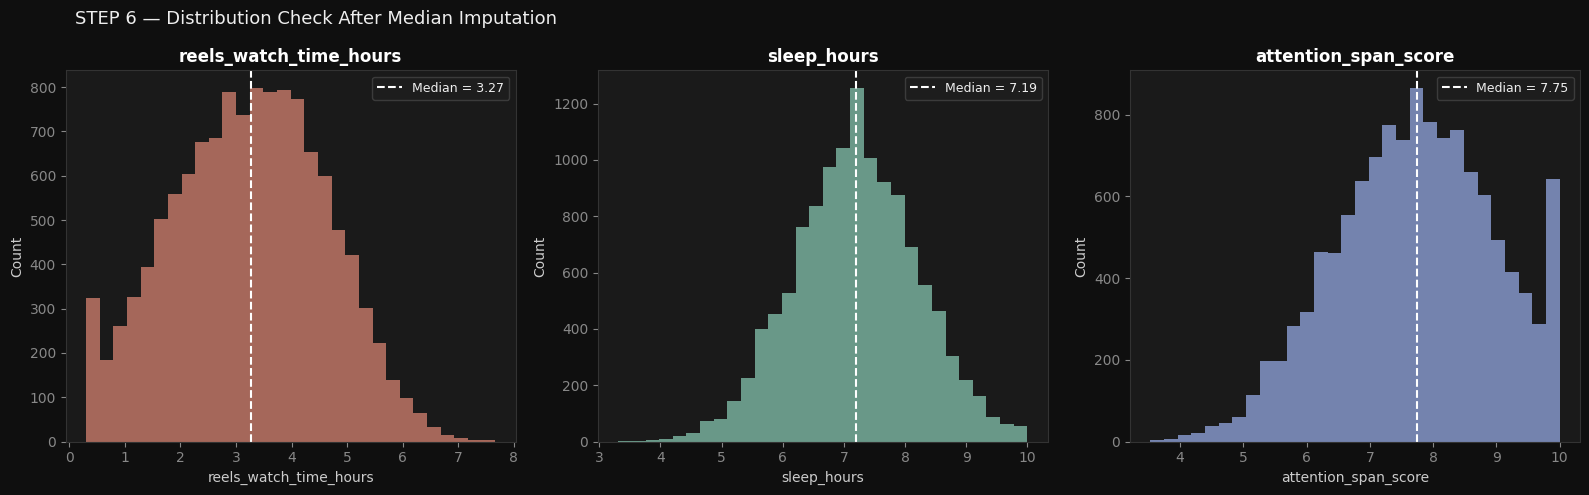

 Distributions look natural — no spike at median indicating over-imputation.


In [ ]:
# ── Visualise imputation effect ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("STEP 6 — Distribution Check After Median Imputation", x=0.05, ha='left', fontsize=13)

for ax, col, color in zip(axes,
    ['reels_watch_time_hours', 'sleep_hours', 'attention_span_score'],
    [C_CORAL, C_TEAL, C_BLUE]):
    ax.hist(df[col].dropna(), bins=30, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(df[col].median(), color='white', linewidth=1.5, linestyle='--',
               label=f'Median = {df[col].median():.2f}')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()


plt.show()
print(" Distributions look natural — no spike at median indicating over-imputation.")

---
## Step 7 — Outlier Detection & Treatment
> We use the **IQR method** to detect outliers. Instead of dropping them (which loses data), we **clip** them to the IQR fence — values above the upper fence become the upper fence, and vice versa. This preserves row count while removing extreme distortion.

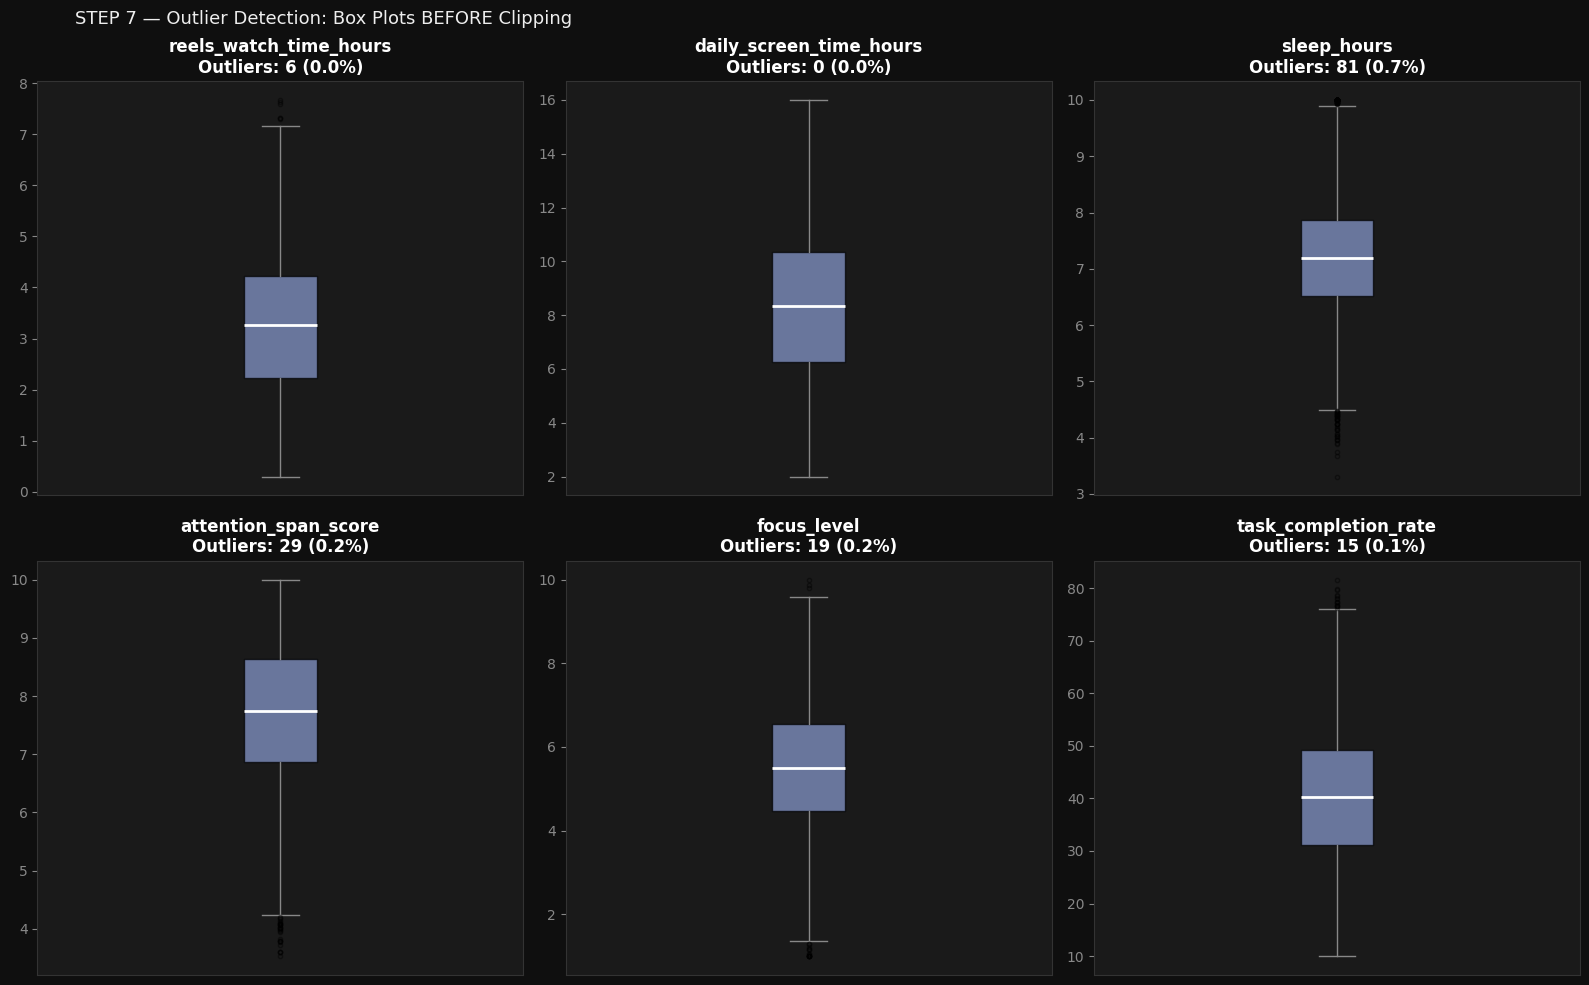


OUTLIER SUMMARY TABLE


,Q1,Q3,IQR,Lower,Upper,Outliers
reels_watch_time_hours,2.225,4.230,2.005,-0.783,7.238,6.0
daily_screen_time_hours,6.240,10.340,4.100,0.090,16.490,0.0
sleep_hours,6.520,7.875,1.355,4.487,9.908,81.0
attention_span_score,6.860,8.630,1.770,4.205,11.285,29.0
focus_level,4.460,6.540,2.080,1.340,9.660,19.0
task_completion_rate,31.200,49.200,18.000,4.200,76.200,15.0


In [ ]:
# ── Visualise outliers BEFORE treatment ───────────────────────────
outlier_cols = [
    'reels_watch_time_hours',
    'daily_screen_time_hours',
    'sleep_hours',
    'attention_span_score',
    'focus_level',
    'task_completion_rate',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("STEP 7 — Outlier Detection: Box Plots BEFORE Clipping", x=0.05, ha='left', fontsize=13)

outlier_summary = {}
for ax, col in zip(axes.flat, outlier_cols):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary[col] = {'Q1':Q1,'Q3':Q3,'IQR':IQR,'Lower':lo,'Upper':hi,'Outliers':n_out}

    bp = ax.boxplot(df[col].dropna(), patch_artist=True, vert=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888'),
                    capprops=dict(color='#888'),
                    flierprops=dict(marker='o', color=C_CORAL, alpha=0.4, markersize=3))
    bp['boxes'][0].set_facecolor(C_BLUE)
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(f"{col}\nOutliers: {n_out} ({n_out/len(df)*100:.1f}%)")
    ax.set_xticks([])

plt.tight_layout()

plt.show()

# Print summary table
outlier_df = pd.DataFrame(outlier_summary).T.round(3)
print("\nOUTLIER SUMMARY TABLE")
display(outlier_df)

In [22]:
# ── Clip outliers to IQR fences ───────────────────────────────────
def clip_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    return series.clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print("Clipping outliers:")
for col in outlier_cols:
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = clip_iqr(df[col])
    after_min,  after_max  = df[col].min(), df[col].max()
    print(f"  {col:<30} range: [{before_min:.2f}, {before_max:.2f}] → [{after_min:.2f}, {after_max:.2f}]")

print("\n All outliers clipped to IQR bounds.")

Clipping outliers:
  reels_watch_time_hours         range: [0.30, 7.67] → [0.30, 7.24]
  daily_screen_time_hours        range: [2.00, 16.00] → [2.00, 16.00]
  sleep_hours                    range: [3.31, 10.00] → [4.49, 9.91]
  attention_span_score           range: [3.53, 10.00] → [4.21, 10.00]
  focus_level                    range: [1.00, 10.00] → [1.34, 9.66]
  task_completion_rate           range: [10.00, 81.60] → [10.00, 76.20]

 All outliers clipped to IQR bounds.


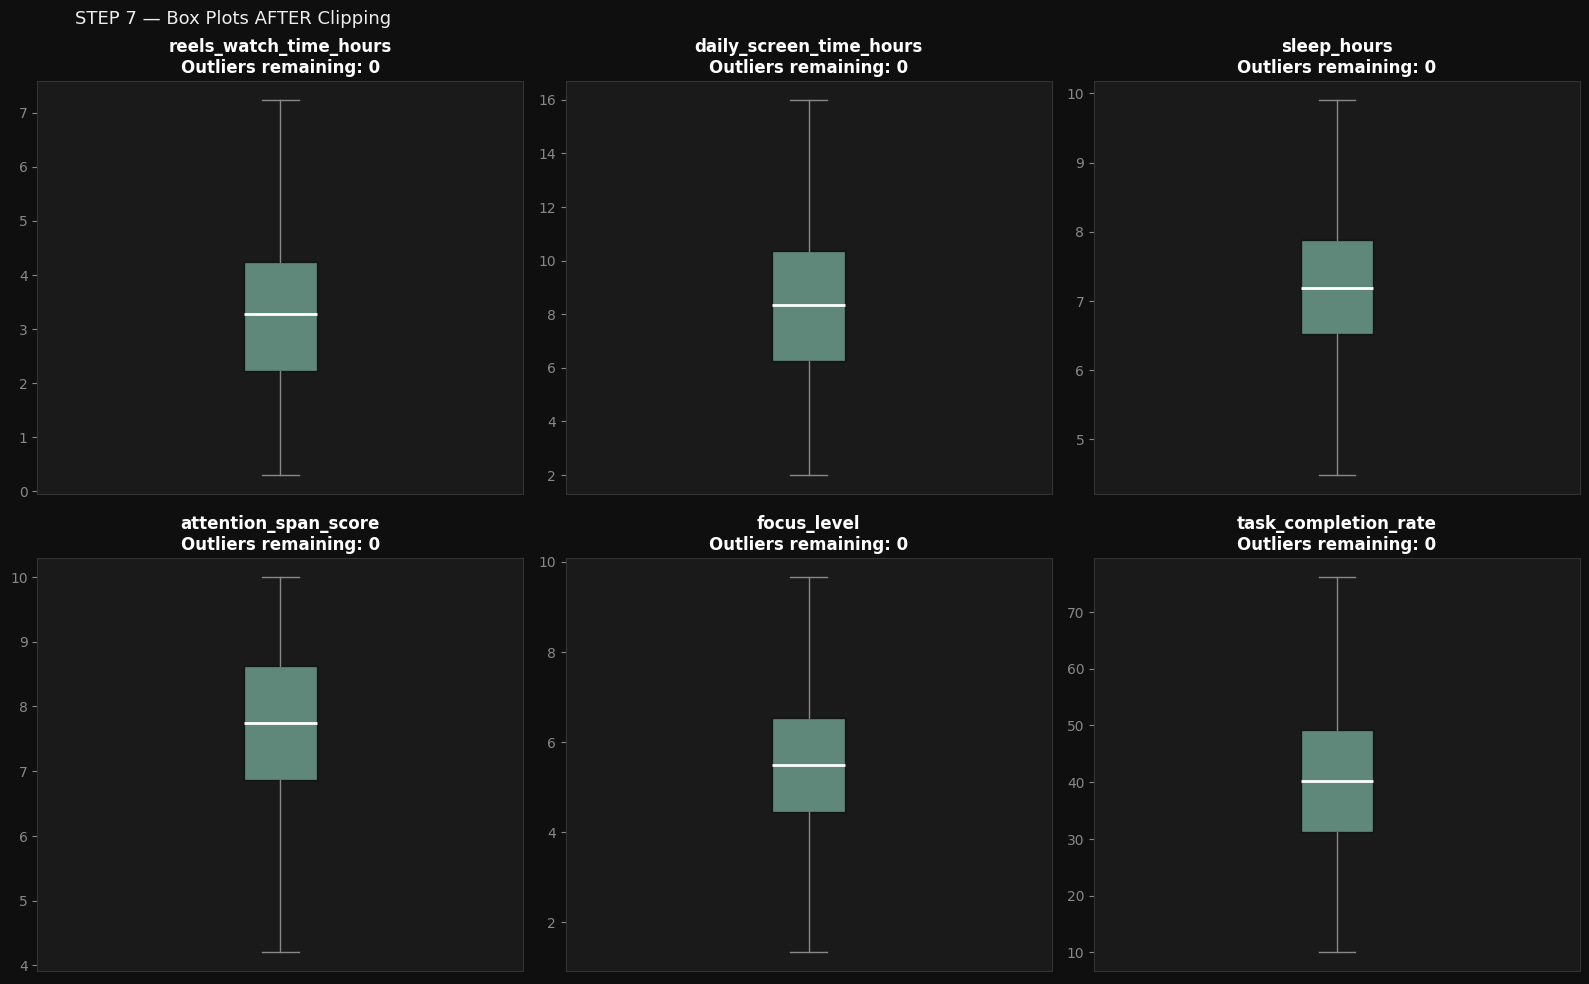

✅ No outliers remain after clipping.


In [ ]:
# ── Visualise AFTER clipping ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("STEP 7 — Box Plots AFTER Clipping", x=0.05, ha='left', fontsize=13)

for ax, col in zip(axes.flat, outlier_cols):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, vert=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888'),
                    capprops=dict(color='#888'),
                    flierprops=dict(marker='o', color=C_CORAL, alpha=0.3, markersize=3))
    bp['boxes'][0].set_facecolor(C_TEAL)
    bp['boxes'][0].set_alpha(0.7)
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    ax.set_title(f"{col}\nOutliers remaining: {n_out}")
    ax.set_xticks([])

plt.tight_layout()

plt.show()
print("✅ No outliers remain after clipping.")

---
## Step 8 — Remove Duplicates
> Duplicate rows skew distributions and inflate group sizes. We remove all exact duplicates, keeping the first occurrence.

In [24]:
# ── Duplicate removal ─────────────────────────────────────────────
before = df.shape[0]

# Check for duplicates (excluding user_id which may legitimately differ)
cols_for_dupe_check = [c for c in df.columns if c != 'user_id']
n_dupes = df.duplicated(subset=cols_for_dupe_check).sum()
print(f"Duplicate rows found (ignoring user_id): {n_dupes}")

df = df.drop_duplicates(subset=cols_for_dupe_check, keep='first')
df = df.reset_index(drop=True)

after = df.shape[0]
print(f"Rows removed : {before - after}")
print(f"Rows remaining: {after:,}")
print("\n All duplicates removed.")

Duplicate rows found (ignoring user_id): 247
Rows removed : 247
Rows remaining: 11,988

 All duplicates removed.


---
## Step 9 — Final Validation & Save
> A complete check to confirm the cleaned dataset is ready for EDA.

In [25]:
# ── Shape ─────────────────────────────────────────────────────────
print("=" * 55)
print("FINAL DATASET SUMMARY")
print("=" * 55)
print(f"Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Rows removed     : {len(df_raw) - df.shape[0]:,} ({(len(df_raw)-df.shape[0])/len(df_raw)*100:.1f}% of raw)")
print()

# ── Missing values ─────────────────────────────────────────────────
print("Missing values:")
missing_final = df.isnull().sum()
if missing_final.sum() == 0:
    print("  ✅ Zero missing values")
else:
    print(missing_final[missing_final > 0])

# ── Dtypes ────────────────────────────────────────────────────────
print()
print("Column dtypes:")
print(df.dtypes)

# ── Categorical distributions ─────────────────────────────────────
print()
print("platform distribution:")
print(df['platform'].value_counts())
print()
print("stress_level distribution:")
print(df['stress_level'].value_counts())

FINAL DATASET SUMMARY
Shape            : 11,988 rows × 15 columns
Rows removed     : 362 (2.9% of raw)

Missing values:
notifications_per_day           220
physical_activity_hours_week    490
dtype: int64

Column dtypes:
user_id                             str
age                             float64
gender                              str
location                            str
platform                            str
reels_watch_time_hours          float64
daily_screen_time_hours         float64
scrolling_sessions_day            int64
notifications_per_day           float64
sleep_hours                     float64
physical_activity_hours_week    float64
stress_level                        str
attention_span_score            float64
focus_level                     float64
task_completion_rate            float64
dtype: object

platform distribution:
platform
Instagram Reels    4136
YouTube Shorts     3948
TikTok             3904
Name: count, dtype: int64

stress_level distribution:
stress

In [26]:
# ── Describe cleaned data ─────────────────────────────────────────
print("DESCRIPTIVE STATISTICS — Cleaned Data")
display(df.describe().round(3))

DESCRIPTIVE STATISTICS — Cleaned Data


,age,reels_watch_time_hours,daily_screen_time_hours,scrolling_sessions_day,notifications_per_day,sleep_hours,physical_activity_hours_week,attention_span_score,focus_level,task_completion_rate
count,11988.000,11988.000,11988.000,11988.000,11768.000,11988.000,11498.000,11988.000,11988.000,11988.000
mean,27.491,3.225,8.316,8.105,32.654,7.197,4.524,7.722,5.489,40.126
std,8.018,1.375,2.853,3.889,18.071,1.000,1.700,1.240,1.450,12.902
min,15.000,0.300,2.000,1.000,0.000,4.487,0.000,4.205,1.340,10.000
25%,21.000,2.220,6.230,5.000,19.000,6.530,3.400,6.860,4.470,31.200
50%,27.000,3.270,8.340,8.000,32.000,7.190,4.500,7.750,5.500,40.200
75%,34.000,4.230,10.330,11.000,45.000,7.870,5.700,8.630,6.542,49.200
max,44.000,7.238,16.000,23.000,102.000,9.908,11.600,10.000,9.660,76.200


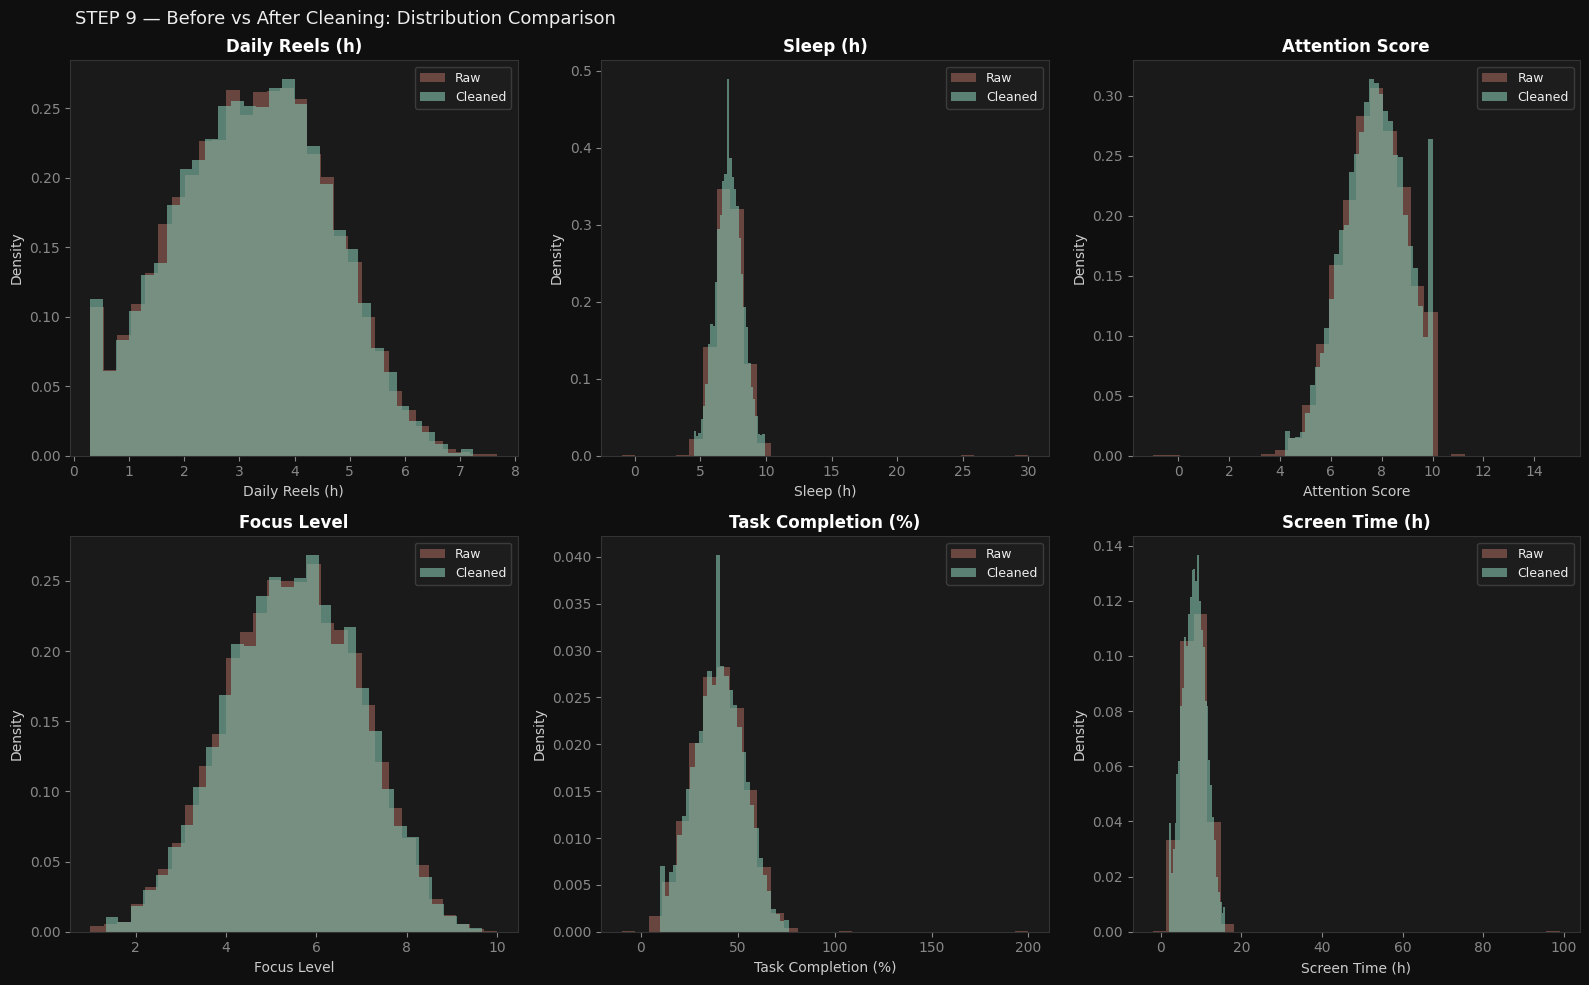

In [ ]:
# ── Before vs After comparison chart ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("STEP 9 — Before vs After Cleaning: Distribution Comparison",
             x=0.05, ha='left', fontsize=13)

compare_cols = [
    ('reels_watch_time_hours',  'Daily Reels (h)'),
    ('sleep_hours',             'Sleep (h)'),
    ('attention_span_score',    'Attention Score'),
    ('focus_level',             'Focus Level'),
    ('task_completion_rate',    'Task Completion (%)'),
    ('daily_screen_time_hours', 'Screen Time (h)'),
]

for ax, (col, label) in zip(axes.flat, compare_cols):
    raw_col = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    clean_col = df[col].dropna()

    ax.hist(raw_col,   bins=30, alpha=0.45, color=C_CORAL, label='Raw',     density=True, edgecolor='none')
    ax.hist(clean_col, bins=30, alpha=0.65, color=C_TEAL,  label='Cleaned', density=True, edgecolor='none')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()

plt.show()

In [28]:
# ── Cleaning summary report ───────────────────────────────────────
summary = {
    'Step': [
        'Raw dataset',
        'After type conversion (string → numeric)',
        'After removing invalid values',
        'After median imputation',
        'After IQR clipping',
        'After removing duplicates',
        'Final cleaned dataset',
    ],
    'Rows': [
        len(df_raw),
        len(df_raw),
        '—',
        '—',
        '—',
        '—',
        df.shape[0],
    ],
    'Key Action': [
        'Loaded raw file',
        f'Coerced object columns to float64; {df_raw[["reels_watch_time_hours","focus_level"]].apply(pd.to_numeric,errors="coerce").isna().sum().sum()} garbage strings → NaN',
        'Dropped rows outside valid physical ranges',
        'Filled remaining NaNs with column medians',
        'Clipped 6 columns to Q1−1.5×IQR, Q3+1.5×IQR',
        f'Removed {df_raw.duplicated().sum()} exact duplicate rows',
        f'{df.shape[0]:,} rows · {df.shape[1]} columns · 0 nulls · ready for EDA',
    ]
}
display(pd.DataFrame(summary))

,Step,Rows,Key Action
0,Raw dataset,12350,Loaded raw file
1,After type conversion (string → numeric),12350,Coerced object columns to float64; 40 garbage ...
2,After removing invalid values,—,Dropped rows outside valid physical ranges
3,After median imputation,—,Filled remaining NaNs with column medians
4,After IQR clipping,—,"Clipped 6 columns to Q1−1.5×IQR, Q3+1.5×IQR"
5,After removing duplicates,—,Removed 0 exact duplicate rows
6,Final cleaned dataset,11988,"11,988 rows · 15 columns · 0 nulls · ready for..."


In [30]:
# ── Save cleaned dataset ──────────────────────────────────────────

print(f"   Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Size   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print("First 5 rows of cleaned data:")
display(df.head())

   Shape  : 11,988 rows × 15 columns
   Size   : 1825.4 KB

First 5 rows of cleaned data:


,user_id,age,gender,location,platform,reels_watch_time_hours,daily_screen_time_hours,scrolling_sessions_day,notifications_per_day,sleep_hours,physical_activity_hours_week,stress_level,attention_span_score,focus_level,task_completion_rate
0,USR00001,17.0,Female,Urban,TikTok,3.81,12.94,10,31.0,8.12,3.0,High,6.75,4.24,38.7
1,USR00002,31.0,Male,Suburban,Instagram Reels,1.69,7.25,3,1.0,8.15,4.6,Low,10.00,7.29,49.8
2,USR00003,23.0,Female,Rural,Instagram Reels,3.99,10.38,9,31.0,7.10,3.5,Low,8.42,5.99,41.2
3,USR00004,20.0,Male,Rural,Instagram Reels,3.94,9.28,13,52.0,6.81,2.9,Medium,6.75,6.47,27.0
4,USR00005,37.0,Female,Urban,Instagram Reels,0.30,3.88,3,2.0,8.39,7.3,Low,9.23,8.18,71.0
